In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

In [ ]:
carbon = pd.read_csv("carbon_us_19_26.csv", index_col= "date", parse_dates= True)

In [ ]:
carbon.head()

,country,sector,MtCO2 per day
date,,,
01/01/2019,United States,Domestic Aviation,0.363743
01/01/2019,United States,Ground Transport,4.705910
01/01/2019,United States,Industry,2.120490
01/01/2019,United States,International Aviation,0.178948
01/01/2019,United States,Power,3.771470


In [ ]:
carbon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15870 entries, 01/01/2019 to 31/03/2026
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        15870 non-null  object 
 1   sector         15870 non-null  object 
 2   MtCO2 per day  15870 non-null  float64
dtypes: float64(1), object(2)
memory usage: 495.9+ KB


In [ ]:
carbon_df = carbon.pivot_table(index= "date", columns= "sector", values= "MtCO2 per day")
carbon_df.head()

sector,Domestic Aviation,Ground Transport,Industry,International Aviation,Power,Residential
date,,,,,,
01/01/2019,0.363743,4.70591,2.12049,0.178948,3.77147,2.81395
01/01/2020,0.372685,4.78953,2.47434,0.178324,3.49489,3.15591
01/01/2021,0.228923,4.65527,2.31156,0.097180,3.91235,3.12943
01/01/2022,0.307071,2.75498,1.88636,0.157637,3.38126,2.14877
01/01/2023,0.323930,3.40867,2.15984,0.172968,3.22599,2.06694


In [ ]:
carbon_df.index = pd.to_datetime(carbon_df.index, format="%d/%m/%Y")

In [ ]:
carbon_df.sort_index(inplace= True)

In [ ]:
carbon_df.head()

sector,Domestic Aviation,Ground Transport,Industry,International Aviation,Power,Residential
date,,,,,,
2019-01-01,0.363743,4.70591,2.12049,0.178948,3.77147,2.81395
2019-01-02,0.436517,4.94065,2.22424,0.190483,3.95599,3.47507
2019-01-03,0.469240,4.98876,2.53213,0.203517,4.50361,3.20613
2019-01-04,0.456743,5.00355,2.45294,0.203857,4.36275,2.92680
2019-01-05,0.415185,2.86631,2.41715,0.209391,4.29910,2.68456


In [ ]:
carbon_df.columns

Index(['Domestic Aviation', 'Ground Transport', 'Industry',
       'International Aviation', 'Power', 'Residential'],
      dtype='object', name='sector')

In [ ]:
carbon_df.columns = ['Domestic_Aviation', 'Ground_Transport', 'Industry',
       'International_Aviation', 'Power', 'Residential']

In [ ]:
carbon_df

,Domestic_Aviation,Ground_Transport,Industry,International_Aviation,Power,Residential
date,,,,,,
2019-01-01,0.363743,4.70591,2.12049,0.178948,3.77147,2.813950
2019-01-02,0.436517,4.94065,2.22424,0.190483,3.95599,3.475070
2019-01-03,0.469240,4.98876,2.53213,0.203517,4.50361,3.206130
2019-01-04,0.456743,5.00355,2.45294,0.203857,4.36275,2.926800
2019-01-05,0.415185,2.86631,2.41715,0.209391,4.29910,2.684560
...,...,...,...,...,...,...
2026-03-27,0.498419,4.65755,2.50510,0.213608,2.87408,1.320590
2026-03-28,0.461267,4.68396,2.62120,0.219908,3.00729,2.975720
2026-03-29,0.449970,4.65070,2.28607,0.221529,2.62279,2.840030


In [ ]:
snp = yf.download("^GSPC", start= "2019-01-01", end="2026-03-31")["Close"]
snp

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2019-01-02,2510.030029
2019-01-03,2447.889893
2019-01-04,2531.939941
2019-01-07,2549.689941
2019-01-08,2574.409912
...,...
2026-03-24,6556.370117
2026-03-25,6591.899902
2026-03-26,6477.160156


In [ ]:
snp.index = pd.to_datetime(snp.index, format="%Y-%m-%d")
snp.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1820 entries, 2019-01-02 to 2026-03-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^GSPC   1820 non-null   float64
dtypes: float64(1)
memory usage: 28.4 KB


In [ ]:
snp.rename(columns={"^GSPC": "snp_500"}, inplace = True)

In [ ]:
snp.head()

Ticker,snp_500
Date,
2019-01-02,2510.030029
2019-01-03,2447.889893
2019-01-04,2531.939941
2019-01-07,2549.689941
2019-01-08,2574.409912


In [ ]:
carbon_main = carbon_df.merge(snp, left_index= True, right_index= True)
carbon_main.head()

,Domestic_Aviation,Ground_Transport,Industry,International_Aviation,Power,Residential,snp_500
2019-01-02,0.436517,4.94065,2.22424,0.190483,3.95599,3.47507,2510.030029
2019-01-03,0.469240,4.98876,2.53213,0.203517,4.50361,3.20613,2447.889893
2019-01-04,0.456743,5.00355,2.45294,0.203857,4.36275,2.92680,2531.939941
2019-01-07,0.421686,3.78389,1.87905,0.204479,3.34204,2.53096,2549.689941
2019-01-08,0.437056,4.70591,2.15024,0.198693,3.82438,2.22898,2574.409912


In [ ]:
carbon_main.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1819 entries, 2019-01-02 to 2026-03-30
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Domestic_Aviation       1819 non-null   float64
 1   Ground_Transport        1819 non-null   float64
 2   Industry                1819 non-null   float64
 3   International_Aviation  1819 non-null   float64
 4   Power                   1819 non-null   float64
 5   Residential             1819 non-null   float64
 6   snp_500                 1819 non-null   float64
dtypes: float64(7)
memory usage: 113.7 KB


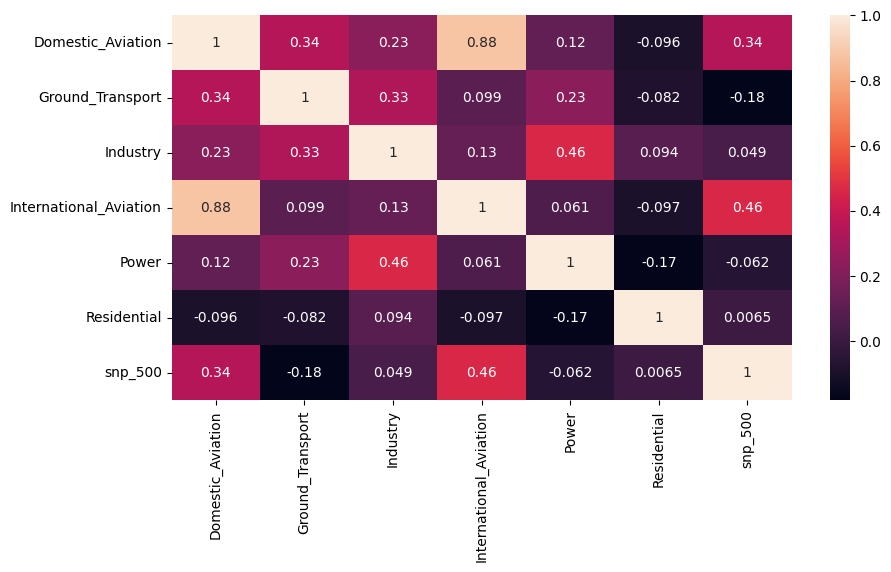

In [ ]:
plt.figure(figsize= (10, 5))
sns.heatmap(carbon_main.corr(), annot= True)
plt.savefig("carbon_heatmap.png")
plt.show()

In [ ]:
carbon_main.to_csv("carbon_snp_500.csv")